<!-- # Copyright (c) 2026 takotime808 -->
# Multi-Fidelity Surrogate Modeling

**What this tutorial covers:**

Many engineering workflows involve simulators or experiments that can be run at different *fidelity levels* — from fast, inaccurate approximations to slow, high-accuracy runs. Multi-fidelity modeling combines data from all levels to build a surrogate that achieves the accuracy of the expensive high-fidelity source while requiring far fewer expensive evaluations.

`multioutreg` ships three multi-fidelity classes:

| Class | Approach | Levels | Cross-fidelity coupling |
|---|---|---|---|
| `MultiFidelitySurrogate` | Independent per-level surrogates | ≥ 1 | None (baseline) |
| `StackedVFMSurrogate` | Recursive feature augmentation (Perdikaris et al. 2017) | ≥ 2 | Full nonlinear |
| `AdditiveCorrectionVFM` | Additive correction f_hi = f_lo + δ (Kennedy & O'Hagan 2000) | 2 | Additive |

All three inherit `ConformalMixin`, so distribution-free prediction intervals via `wrap_conformal` / `conformal_predict` are always available.

## Contents
1. [Motivation & data generation](#motivation)
2. [MultiFidelitySurrogate — independent per-level baseline](#mfs)
3. [StackedVFMSurrogate — nonlinear cross-fidelity coupling](#stacked)
4. [Heterogeneous surrogates and uncertainty augmentation](#hetero)
5. [Three-level VFM](#three)
6. [AdditiveCorrectionVFM — Kennedy-O'Hagan style](#additive)
7. [Conformal prediction intervals](#conformal)
8. [Multi-output example](#multioutput)
9. [Model comparison](#comparison)
10. [When to use which class](#guide)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

from multioutreg.surrogates import (
    MultiFidelitySurrogate,
    StackedVFMSurrogate,
    AdditiveCorrectionVFM,
    RandomForestSurrogate,
    GaussianProcessSurrogate,
    GradientBoostingSurrogate,
    LinearRegressionSurrogate,
    BayesianRidgeSurrogate,
)

rng = np.random.default_rng(42)

def rmse(y_true, y_pred):
    """Root mean squared error, returns one value per output column."""
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))

---
<a id='motivation'></a>
## 1. Motivation & Data Generation

We simulate a one-dimensional aerodynamic drag coefficient benchmark where:

- **Low-fidelity** (panel method): fast, 200 cheap evaluations available.
  $$c_{d,lo}(x) = \sin(\pi x) + 0.3 x^2$$

- **High-fidelity** (RANS CFD): slow, only 25 expensive evaluations available.
  $$c_{d,hi}(x) = c_{d,lo}(x) + 0.25\, x \cos(2\pi x) - 0.15 e^{-4x^2}$$

The ground truth is the high-fidelity function; the goal is to learn it accurately using mostly low-fidelity data.

In [2]:
def lo_fi(x):
    """Low-fidelity response (fast, inaccurate)."""
    return np.sin(np.pi * x) + 0.3 * x**2

def hi_fi(x):
    """High-fidelity response (slow, accurate)."""
    return lo_fi(x) + 0.25 * x * np.cos(2 * np.pi * x) - 0.15 * np.exp(-4 * x**2)

# --- Generate data ---
N_LO = 200   # cheap samples
N_HI = 25    # expensive samples

X_lo = rng.uniform(-2, 2, (N_LO, 1))
Y_lo = lo_fi(X_lo) + rng.normal(0, 0.04, (N_LO, 1))   # small observation noise

X_hi = rng.uniform(-2, 2, (N_HI, 1))
Y_hi = hi_fi(X_hi) + rng.normal(0, 0.02, (N_HI, 1))   # tiny observation noise

# Dense test grid for plotting
X_test = np.linspace(-2, 2, 300).reshape(-1, 1)
Y_test = hi_fi(X_test)

print(f"Low-fidelity:   {N_LO} samples   (cheap)")
print(f"High-fidelity:  {N_HI} samples   (expensive)")

Low-fidelity:   200 samples   (cheap)
High-fidelity:  25 samples   (expensive)


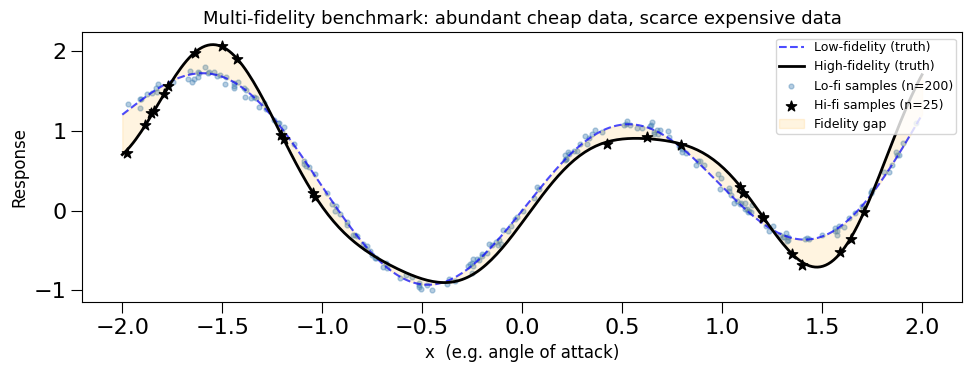

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(X_test, lo_fi(X_test), 'b--', lw=1.5, label='Low-fidelity (truth)', alpha=0.7)
ax.plot(X_test, hi_fi(X_test), 'k-',  lw=2.0, label='High-fidelity (truth)')
ax.scatter(X_lo, Y_lo, s=12, c='steelblue', alpha=0.4, label=f'Lo-fi samples (n={N_LO})')
ax.scatter(X_hi, Y_hi, s=60, c='k', marker='*', zorder=5, label=f'Hi-fi samples (n={N_HI})')

ax.fill_between(X_test.ravel(),
                lo_fi(X_test).ravel(),
                hi_fi(X_test).ravel(),
                alpha=0.12, color='orange', label='Fidelity gap')

ax.set_xlabel('x  (e.g. angle of attack)', fontsize=12)
ax.set_ylabel('Response', fontsize=12)
ax.set_title('Multi-fidelity benchmark: abundant cheap data, scarce expensive data', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

The orange shaded region is the *fidelity gap* — the systematic bias that the low-fidelity model introduces. A naive surrogate trained only on the 25 high-fidelity points will overfit; multi-fidelity models use the abundant low-fidelity data to regularise and improve the fit.

---
<a id='mfs'></a>
## 2. MultiFidelitySurrogate — Independent Per-Level Baseline

`MultiFidelitySurrogate` is the **simplest** multi-fidelity class: it fits a completely independent surrogate at each fidelity level. There is no cross-fidelity information transfer — each surrogate sees only its own level's data.

It is useful as a **baseline** and for workflows where you simply want to query any level at prediction time with a single object.

```python
MultiFidelitySurrogate(
    surrogate_cls,          # class used to instantiate a surrogate per level
    fidelity_levels,        # ordered list of level names
)
```

Fit via a dict `{level: (X, Y)}`; predict by specifying a `level=` keyword.

In [4]:
data = {"lo": (X_lo, Y_lo), "hi": (X_hi, Y_hi)}

mfs = MultiFidelitySurrogate(
    surrogate_cls=RandomForestSurrogate,
    fidelity_levels=["lo", "hi"],
)
mfs.fit(data)

Y_mfs_lo = mfs.predict(X_test, level="lo")
Y_mfs_hi = mfs.predict(X_test, level="hi")

print("MultiFidelity (RF) — independent surrogates")
print(f"  Lo-level RMSE vs hi-fi truth:  {rmse(Y_test, Y_mfs_lo).item():.4f}")
print(f"  Hi-level RMSE vs hi-fi truth:  {rmse(Y_test, Y_mfs_hi).item():.4f}")
print()
print("Note: hi-level trained only on 25 points → may overfit or underfit.")
print("Note: lo-level captures lo-fi trend, not the true hi-fi response.")

MultiFidelity (RF) — independent surrogates
  Lo-level RMSE vs hi-fi truth:  0.2259
  Hi-level RMSE vs hi-fi truth:  0.6402

Note: hi-level trained only on 25 points → may overfit or underfit.
Note: lo-level captures lo-fi trend, not the true hi-fi response.


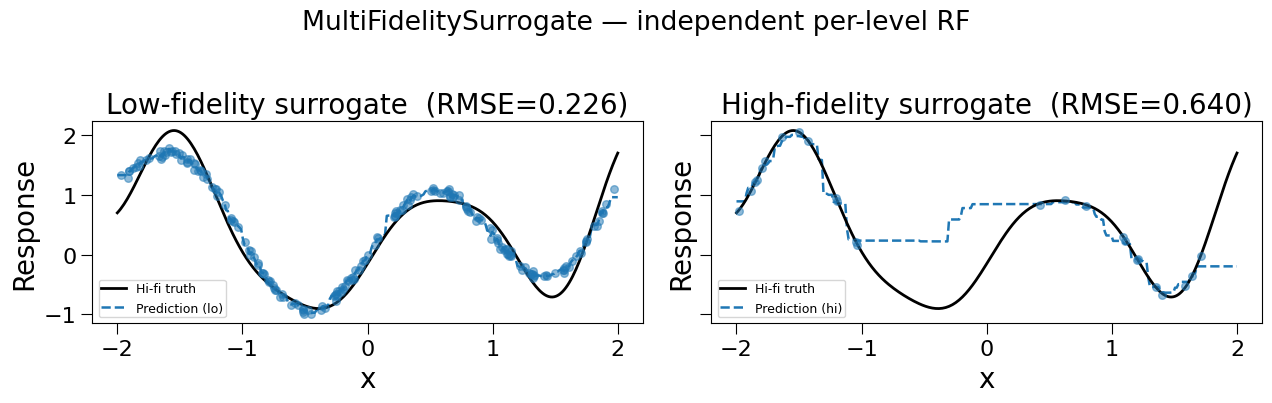

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, (level, Y_pred, label) in zip(axes, [
    ("lo", Y_mfs_lo, "Low-fidelity surrogate"),
    ("hi", Y_mfs_hi, "High-fidelity surrogate"),
]):
    ax.plot(X_test, Y_test, 'k-', lw=2, label='Hi-fi truth', zorder=3)
    ax.plot(X_test, Y_pred, 'tab:blue', lw=1.8, ls='--', label=f'Prediction ({level})')
    ax.scatter(X_lo if level == 'lo' else X_hi,
               Y_lo if level == 'lo' else Y_hi,
               s=30, c='tab:blue', alpha=0.5, zorder=4)
    ax.set_xlabel('x'); ax.set_ylabel('Response')
    ax.set_title(f'{label}  (RMSE={rmse(Y_test, Y_pred).item():.3f})')
    ax.legend(fontsize=9)

plt.suptitle('MultiFidelitySurrogate — independent per-level RF', y=1.02)
plt.tight_layout()
plt.show()

> **Takeaway:** The hi-level surrogate trained on only 25 points is noisy. The lo-level is smooth but biased. Neither exploits the complementary information from the other level.

---
<a id='stacked'></a>
## 3. StackedVFMSurrogate — Nonlinear Cross-Fidelity Coupling

`StackedVFMSurrogate` implements the **recursive feature-augmentation** approach from Perdikaris et al. (2017). At each fidelity level $k > 0$ the input features are **augmented** with all lower-level surrogate predictions before fitting:

$$\tilde{X}_k = \left[X_k \;\Big|\; f_0(X_k) \;\Big|\; f_1(\tilde{X}_k^{(1)}) \;\Big|\; \cdots \right]$$

This allows the high-fidelity surrogate to learn a **nonlinear correction** over the lower-fidelity predictions.

```python
StackedVFMSurrogate(
    fidelity_levels,        # ordered list, lowest → highest
    surrogate_cls,          # one class or list (heterogeneous per level)
    surrogate_params,       # dict or list of dicts
    augment_with_std,       # bool — also augment with predicted stds
)
```

Fit via `model.fit({"lo": (X_lo, Y_lo), "hi": (X_hi, Y_hi)})`.

In [6]:
# Default: Random Forest at every level
stacked = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
)
stacked.fit(data)

Y_stacked = stacked.predict(X_test)

# Baseline: RF trained on hi-fi only (no cross-fidelity)
baseline_hi = RandomForestSurrogate()
baseline_hi.fit(X_hi, Y_hi)
Y_baseline = baseline_hi.predict(X_test)

print("Feature count after augmentation:")
for level, n in stacked.augmented_n_features_per_level_.items():
    print(f"  Level '{level}': {n} features")
print()
print(f"Baseline RF (hi only, n=25) RMSE: {rmse(Y_test, Y_baseline).item():.4f}")
print(f"StackedVFM  (RF/RF)         RMSE: {rmse(Y_test, Y_stacked).item():.4f}")

Feature count after augmentation:
  Level 'lo': 1 features
  Level 'hi': 2 features

Baseline RF (hi only, n=25) RMSE: 0.6544
StackedVFM  (RF/RF)         RMSE: 0.3479


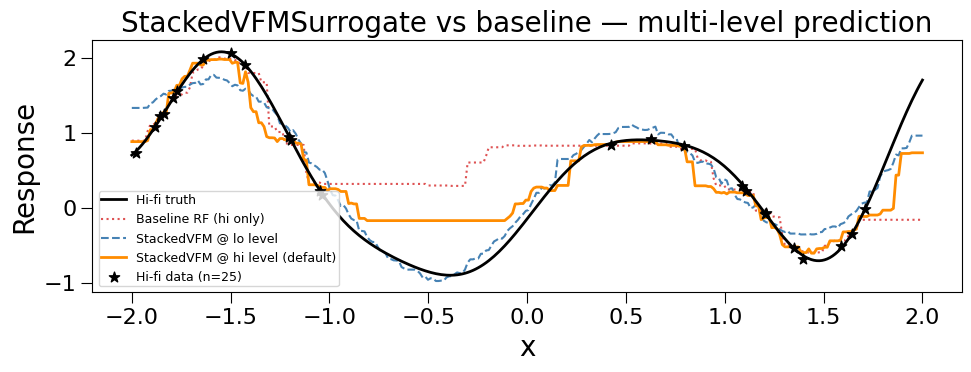

In [7]:
# You can also predict at any intermediate fidelity level
Y_at_lo = stacked.predict(X_test, level="lo")
Y_at_hi = stacked.predict(X_test, level="hi")  # same as default

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(X_test, Y_test,     'k-',          lw=2,   label='Hi-fi truth',           zorder=4)
ax.plot(X_test, Y_baseline, 'tab:red',     lw=1.5, ls=':', label='Baseline RF (hi only)', alpha=0.8)
ax.plot(X_test, Y_at_lo,    'steelblue',   lw=1.5, ls='--', label='StackedVFM @ lo level')
ax.plot(X_test, Y_at_hi,    'darkorange',  lw=2,   label='StackedVFM @ hi level (default)')
ax.scatter(X_hi, Y_hi, s=60, c='k', marker='*', zorder=5, label=f'Hi-fi data (n={N_HI})')
ax.set_xlabel('x'); ax.set_ylabel('Response')
ax.set_title('StackedVFMSurrogate vs baseline — multi-level prediction')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

> **Key insight:** The stacked model's hi-level prediction inherits the smoothness from the abundant low-fidelity data while correcting the bias using the sparse high-fidelity observations.

---
<a id='hetero'></a>
## 4. Heterogeneous Surrogates and Uncertainty Augmentation

A natural choice is a **fast surrogate** at the low-fidelity level (e.g. RF) and a **smooth, uncertainty-aware surrogate** at the high-fidelity level (e.g. GP). Pass lists to `surrogate_cls` and `surrogate_params` to use different models per level.

Setting `augment_with_std=True` also passes the **predicted standard deviation** of level $k$ as an extra feature for level $k+1$, allowing the high-fidelity surrogate to downweight regions where the low-fidelity surrogate is uncertain.

In [8]:
# RF (lo) → GP (hi)
stacked_rf_gp = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
    surrogate_cls=[RandomForestSurrogate, GaussianProcessSurrogate],
    surrogate_params=[{"n_estimators": 100}, {"alpha": 1e-6}],
)
stacked_rf_gp.fit(data)
Y_rf_gp = stacked_rf_gp.predict(X_test)

# RF (lo) → GP (hi) + std augmentation
stacked_std = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
    surrogate_cls=[RandomForestSurrogate, GaussianProcessSurrogate],
    surrogate_params=[{"n_estimators": 100}, {"alpha": 1e-6}],
    augment_with_std=True,
)
stacked_std.fit(data)
Y_std_pred, Y_std_unc = stacked_std.predict(X_test, return_std=True)

print("Augmented features with std augmentation:", stacked_std.augmented_n_features_per_level_)
print("  (lo: 1 feature, hi: 1 original + 1 lo-pred + 1 lo-std = 3 features)")
print()
print(f"RF/RF stacked          RMSE: {rmse(Y_test, Y_stacked).item():.4f}")
print(f"RF→GP stacked          RMSE: {rmse(Y_test, Y_rf_gp).item():.4f}")
print(f"RF→GP + std augment    RMSE: {rmse(Y_test, Y_std_pred).item():.4f}")

Augmented features with std augmentation: {'lo': 1, 'hi': 3}
  (lo: 1 feature, hi: 1 original + 1 lo-pred + 1 lo-std = 3 features)

RF/RF stacked          RMSE: 0.3479
RF→GP stacked          RMSE: 1.2975
RF→GP + std augment    RMSE: 1.1526


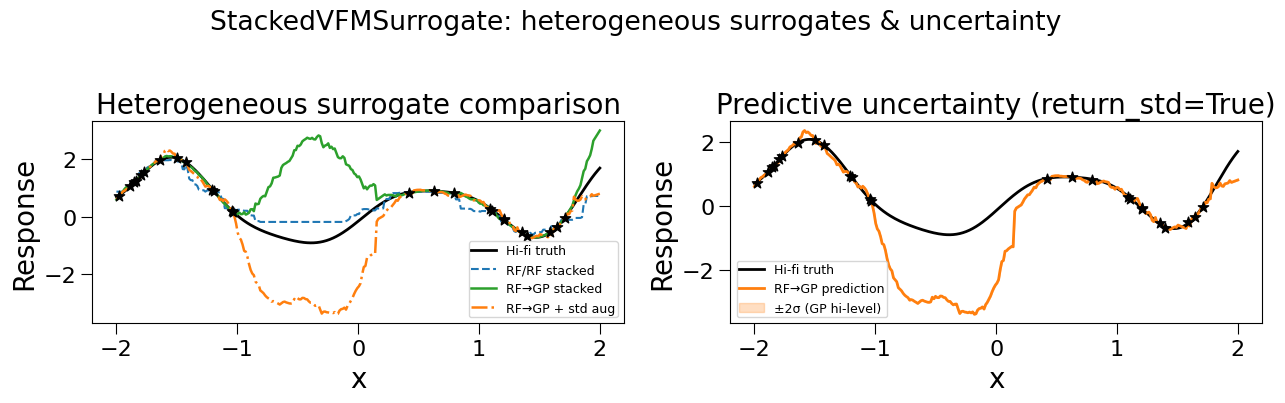

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: predictions
ax = axes[0]
ax.plot(X_test, Y_test,      'k-',         lw=2,   label='Hi-fi truth')
ax.plot(X_test, Y_stacked,   'tab:blue',   lw=1.5, ls='--', label='RF/RF stacked')
ax.plot(X_test, Y_rf_gp,     'tab:green',  lw=1.8, label='RF→GP stacked')
ax.plot(X_test, Y_std_pred,  'tab:orange', lw=1.8, ls='-.', label='RF→GP + std aug')
ax.scatter(X_hi, Y_hi, s=60, c='k', marker='*', zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('Response')
ax.set_title('Heterogeneous surrogate comparison')
ax.legend(fontsize=9)

# Right: GP predictive uncertainty from the high-level model
ax = axes[1]
ax.plot(X_test, Y_test,     'k-', lw=2, label='Hi-fi truth')
ax.plot(X_test, Y_std_pred, 'tab:orange', lw=2, label='RF→GP prediction')
ax.fill_between(X_test.ravel(),
                (Y_std_pred - 2 * Y_std_unc).ravel(),
                (Y_std_pred + 2 * Y_std_unc).ravel(),
                alpha=0.25, color='tab:orange', label='±2σ (GP hi-level)')
ax.scatter(X_hi, Y_hi, s=60, c='k', marker='*', zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('Response')
ax.set_title('Predictive uncertainty (return_std=True)')
ax.legend(fontsize=9)

plt.suptitle('StackedVFMSurrogate: heterogeneous surrogates & uncertainty', y=1.02)
plt.tight_layout()
plt.show()

> **Note on `return_std=True`:** Only the intrinsic std of the **highest-level surrogate** is returned. Uncertainty accumulated through lower-level predictions is not analytically propagated (this would require Monte Carlo sampling). For calibrated intervals use `conformal_predict` (Section 7).

---
<a id='three'></a>
## 5. Three-Level VFM

`StackedVFMSurrogate` generalises naturally to any number of levels. The feature augmentation chain is applied recursively: level 2 sees `[X | pred_0 | pred_1]`, level 3 sees `[X | pred_0 | pred_1 | pred_2]`, and so on.

Here we add a **medium-fidelity** tier (e.g. RANS with coarser grid) between the cheap panel method and the expensive high-fidelity CFD.

In [10]:
def med_fi(x):
    """Medium-fidelity response — closer to hi-fi than lo-fi, but cheaper."""
    return lo_fi(x) + 0.12 * x * np.cos(2 * np.pi * x)

N_MED = 60
X_med = rng.uniform(-2, 2, (N_MED, 1))
Y_med = med_fi(X_med) + rng.normal(0, 0.03, (N_MED, 1))

data_3 = {
    "lo":  (X_lo,  Y_lo),
    "med": (X_med, Y_med),
    "hi":  (X_hi,  Y_hi),
}

stacked_3 = StackedVFMSurrogate(
    fidelity_levels=["lo", "med", "hi"],
    surrogate_cls=[
        RandomForestSurrogate,      # lo: fast and plentiful
        GradientBoostingSurrogate,  # med: moderate cost
        GaussianProcessSurrogate,   # hi: smooth GP correction
    ],
)
stacked_3.fit(data_3)

Y_3 = stacked_3.predict(X_test)

print("Sample counts:  lo=%d, med=%d, hi=%d" % (N_LO, N_MED, N_HI))
print("Augmented feature sizes:", stacked_3.augmented_n_features_per_level_)
print()
print(f"Baseline RF (hi only)      RMSE: {rmse(Y_test, Y_baseline).item():.4f}")
print(f"StackedVFM 2-level (RF/RF) RMSE: {rmse(Y_test, Y_stacked).item():.4f}")
print(f"StackedVFM 3-level         RMSE: {rmse(Y_test, Y_3).item():.4f}")

Sample counts:  lo=200, med=60, hi=25
Augmented feature sizes: {'lo': 1, 'med': 2, 'hi': 3}

Baseline RF (hi only)      RMSE: 0.6544
StackedVFM 2-level (RF/RF) RMSE: 0.3479
StackedVFM 3-level         RMSE: 5.1448


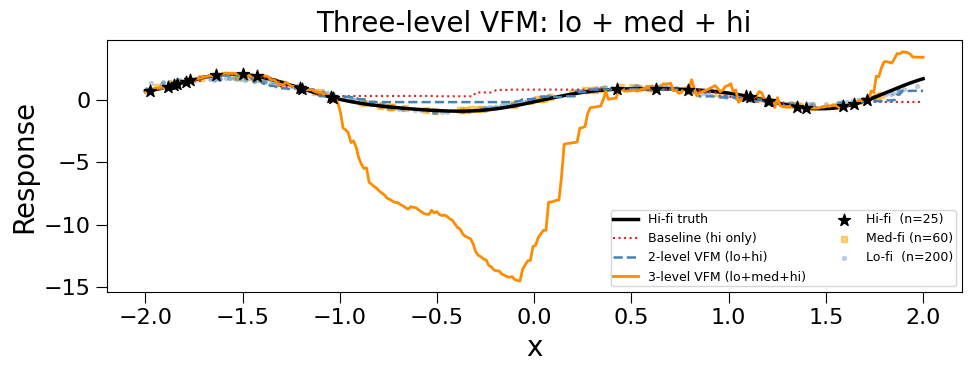

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(X_test, Y_test,      'k-',        lw=2.5, label='Hi-fi truth')
ax.plot(X_test, Y_baseline,  'tab:red',   lw=1.5, ls=':', label='Baseline (hi only)')
ax.plot(X_test, Y_stacked,   'steelblue', lw=1.8, ls='--', label='2-level VFM (lo+hi)')
ax.plot(X_test, Y_3,         'darkorange',lw=2,   label='3-level VFM (lo+med+hi)')

ax.scatter(X_hi,  Y_hi,  s=80, c='k',       marker='*', zorder=5, label=f'Hi-fi  (n={N_HI})')
ax.scatter(X_med, Y_med, s=20, c='orange',   marker='s', alpha=0.5, label=f'Med-fi (n={N_MED})')
ax.scatter(X_lo,  Y_lo,  s=8,  c='steelblue',alpha=0.3,            label=f'Lo-fi  (n={N_LO})')

ax.set_xlabel('x'); ax.set_ylabel('Response')
ax.set_title('Three-level VFM: lo + med + hi')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

---
<a id='additive'></a>
## 6. AdditiveCorrectionVFM — Kennedy-O'Hagan Style

`AdditiveCorrectionVFM` models the high-fidelity response as:

$$f_{hi}(x) = f_{lo}(x) + \delta(x)$$

where $\delta(x) = Y_{hi} - f_{lo}(X_{hi})$ is the additive correction learned from the high-fidelity data. At prediction time both surrogates are evaluated and their outputs summed.

Uncertainty is combined in **quadrature** (assuming independence):

$$\sigma_{hi}(x) = \sqrt{\sigma_{lo}(x)^2 + \sigma_\delta(x)^2}$$

The method `predict_components(X)` returns `(f_lo, delta)` separately for diagnostics.

```python
AdditiveCorrectionVFM(
    lo_surrogate_cls,       # default: RandomForestSurrogate
    hi_surrogate_cls,       # default: GaussianProcessSurrogate (for delta)
    lo_surrogate_params,
    hi_surrogate_params,
)
```

Pass `data = {"lo": (X_lo, Y_lo), "hi": (X_hi, Y_hi)}` to `fit()`.

In [12]:
additive = AdditiveCorrectionVFM(
    lo_surrogate_cls=RandomForestSurrogate,
    hi_surrogate_cls=GaussianProcessSurrogate,    # GP is a natural prior for the correction
    lo_surrogate_params={"n_estimators": 200},
    hi_surrogate_params={"alpha": 1e-6},
)
additive.fit(data)

Y_add, Y_add_std = additive.predict(X_test, return_std=True)
Y_lo_part, Y_delta_part = additive.predict_components(X_test)

print(f"AdditiveCorrectionVFM RMSE:                 {rmse(Y_test, Y_add).item():.4f}")
print(f"StackedVFM (RF/RF)    RMSE:                 {rmse(Y_test, Y_stacked).item():.4f}")
print()
print(f"Mean |f_lo(x)|:   {np.abs(Y_lo_part).mean():.4f}")
print(f"Mean |delta(x)|:  {np.abs(Y_delta_part).mean():.4f}  (correction magnitude)")

AdditiveCorrectionVFM RMSE:                 0.4841
StackedVFM (RF/RF)    RMSE:                 0.3479

Mean |f_lo(x)|:   0.7437
Mean |delta(x)|:  0.3843  (correction magnitude)


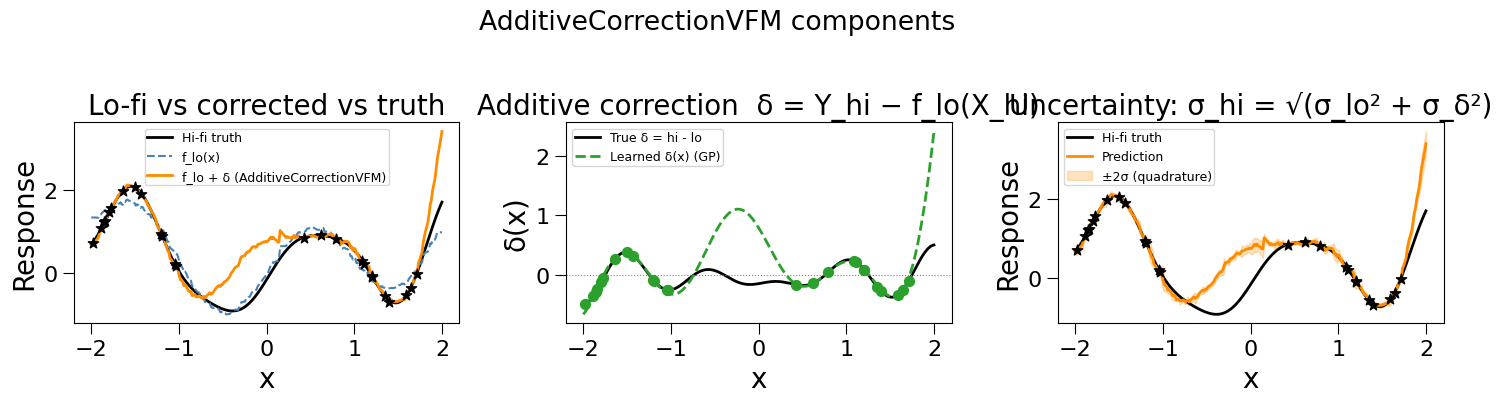

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: lo-fi vs corrected vs truth
ax = axes[0]
ax.plot(X_test, Y_test,       'k-',        lw=2,   label='Hi-fi truth')
ax.plot(X_test, Y_lo_part,    'steelblue', lw=1.5, ls='--', label='f_lo(x)')
ax.plot(X_test, Y_add,        'darkorange',lw=2,   label='f_lo + δ (AdditiveCorrectionVFM)')
ax.scatter(X_hi, Y_hi, s=60, c='k', marker='*', zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('Response')
ax.set_title('Lo-fi vs corrected vs truth')
ax.legend(fontsize=9)

# Panel 2: the additive correction delta(x)
ax = axes[1]
true_delta = hi_fi(X_test) - lo_fi(X_test)
ax.plot(X_test, true_delta,    'k-',        lw=2,   label='True δ = hi - lo')
ax.plot(X_test, Y_delta_part,  'tab:green', lw=2,   ls='--', label='Learned δ(x) (GP)')
ax.axhline(0, c='gray', lw=0.8, ls=':')
ax.scatter(X_hi, hi_fi(X_hi) - lo_fi(X_hi), s=50, c='tab:green', marker='o', zorder=4)
ax.set_xlabel('x'); ax.set_ylabel('δ(x)')
ax.set_title('Additive correction  δ = Y_hi − f_lo(X_hi)')
ax.legend(fontsize=9)

# Panel 3: combined uncertainty
ax = axes[2]
ax.plot(X_test, Y_test, 'k-', lw=2, label='Hi-fi truth')
ax.plot(X_test, Y_add,  'darkorange', lw=2, label='Prediction')
ax.fill_between(X_test.ravel(),
                (Y_add - 2 * Y_add_std).ravel(),
                (Y_add + 2 * Y_add_std).ravel(),
                alpha=0.25, color='darkorange', label='±2σ (quadrature)')
ax.scatter(X_hi, Y_hi, s=60, c='k', marker='*', zorder=5)
ax.set_xlabel('x'); ax.set_ylabel('Response')
ax.set_title('Uncertainty: σ_hi = √(σ_lo² + σ_δ²)')
ax.legend(fontsize=9)

plt.suptitle('AdditiveCorrectionVFM components', y=1.02)
plt.tight_layout()
plt.show()

> **When to use `AdditiveCorrectionVFM`:** When the fidelity gap is well-approximated by a smooth additive shift and you want a simple, interpretable decomposition with `predict_components`. `StackedVFMSurrogate` can capture more complex (multiplicative, regional) gaps.

---
<a id='conformal'></a>
## 7. Conformal Prediction Intervals

Both `StackedVFMSurrogate` and `AdditiveCorrectionVFM` inherit `ConformalMixin`. The conformal workflow:

1. **Fit** the model on training data.
2. **Calibrate** on a held-out set: `model.wrap_conformal(X_cal, y_cal)`.
3. **Predict** intervals: `y_lo, y_hi = model.conformal_predict(X_test, alpha=0.1)`.

This produces **distribution-free** intervals with guaranteed marginal $(1 - \alpha)$ coverage, regardless of model mis-specification.

In [14]:
# Split hi-fi data into train and calibration
idx = rng.permutation(N_HI)
n_cal = 8
X_hi_tr, Y_hi_tr = X_hi[idx[n_cal:]], Y_hi[idx[n_cal:]]
X_hi_cal, Y_hi_cal = X_hi[idx[:n_cal]], Y_hi[idx[:n_cal]]

data_cp = {"lo": (X_lo, Y_lo), "hi": (X_hi_tr, Y_hi_tr)}

# Fit and calibrate StackedVFM
cp_stacked = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
    surrogate_cls=[RandomForestSurrogate, GaussianProcessSurrogate],
)
cp_stacked.fit(data_cp)
cp_stacked.wrap_conformal(X_hi_cal, Y_hi_cal)

# Conformal intervals at 90% target coverage
Y_lower, Y_upper = cp_stacked.conformal_predict(X_test, alpha=0.1)
Y_cp_pred = cp_stacked.predict(X_test)

coverage = np.mean((Y_test >= Y_lower) & (Y_test <= Y_upper))
mean_width = (Y_upper - Y_lower).mean()

print(f"Target coverage: 90%   Achieved: {coverage:.1%}")
print(f"Mean interval width: {mean_width:.4f}")

Target coverage: 90%   Achieved: 49.0%
Mean interval width: 0.1316


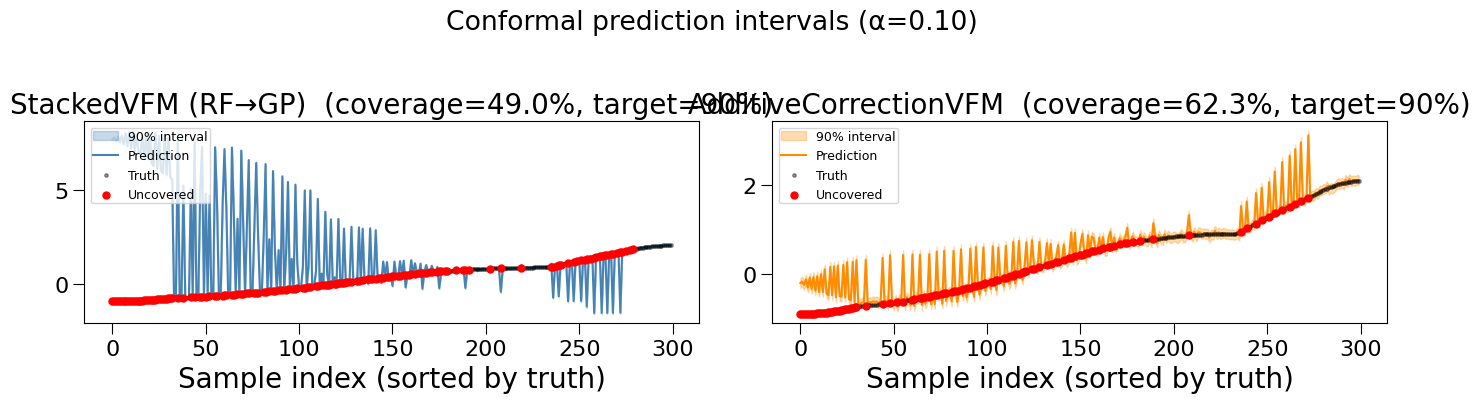

In [15]:
# Also calibrate the additive model
cp_add = AdditiveCorrectionVFM(
    lo_surrogate_cls=RandomForestSurrogate,
    hi_surrogate_cls=GaussianProcessSurrogate,
    hi_surrogate_params={"alpha": 1e-6},
)
cp_add.fit(data_cp)
cp_add.wrap_conformal(X_hi_cal, Y_hi_cal)
Y_lower_add, Y_upper_add = cp_add.conformal_predict(X_test, alpha=0.1)
Y_cp_add_pred = cp_add.predict(X_test)

coverage_add = np.mean((Y_test >= Y_lower_add) & (Y_test <= Y_upper_add))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (pred, lo, hi, title, col, cov) in zip(axes, [
    (Y_cp_pred,     Y_lower,     Y_upper,     'StackedVFM (RF→GP)',        'steelblue',  coverage),
    (Y_cp_add_pred, Y_lower_add, Y_upper_add, 'AdditiveCorrectionVFM',     'darkorange', coverage_add),
]):
    order = np.argsort(Y_test.ravel())
    xs = np.arange(len(order))
    ax.fill_between(xs, lo[order, 0], hi[order, 0], alpha=0.3, color=col, label='90% interval')
    ax.plot(xs, pred[order, 0], lw=1.5, color=col, label='Prediction')
    ax.scatter(xs, Y_test[order, 0], s=6, c='k', alpha=0.4, label='Truth', zorder=3)
    uncovered = (Y_test[order, 0] < lo[order, 0]) | (Y_test[order, 0] > hi[order, 0])
    if uncovered.any():
        ax.scatter(xs[uncovered], Y_test[order, 0][uncovered], s=25, c='red', zorder=4, label='Uncovered')
    ax.set_title(f'{title}  (coverage={cov:.1%}, target=90%)')
    ax.set_xlabel('Sample index (sorted by truth)')
    ax.legend(fontsize=9, loc='upper left')

plt.suptitle('Conformal prediction intervals (α=0.10)', y=1.02)
plt.tight_layout()
plt.show()

> **Coverage guarantee:** Conformal prediction is *distribution-free* — the coverage guarantee holds for any well-specified surrogate under the mild exchangeability assumption. The calibration residuals define the interval width; a larger calibration set gives tighter, better-calibrated intervals.

---
<a id='multioutput'></a>
## 8. Multi-Output Example

All three classes natively handle multi-output responses. Pass `Y` arrays with shape `(n_samples, n_outputs)` — both fidelity levels must share the same output dimensionality for `AdditiveCorrectionVFM`, while `StackedVFMSurrogate` can handle mismatched dimensions via the `output_dim_mismatch` parameter.

In [16]:
# Multi-output: drag coefficient AND lift coefficient
def lo_fi_mo(X):
    x1, x2 = X[:, 0], X[:, 1]
    cd = np.sin(np.pi * x1) + 0.3 * x1**2                     # drag
    cl = np.cos(np.pi * x2) + 0.2 * x1 * x2                   # lift
    return np.column_stack([cd, cl])

def hi_fi_mo(X):
    Y_lo = lo_fi_mo(X)
    x1, x2 = X[:, 0], X[:, 1]
    delta_cd = 0.25 * x1 * np.cos(2 * np.pi * x1) - 0.15 * np.exp(-4 * x1**2)
    delta_cl = 0.15 * np.sin(3 * np.pi * x2) * x1
    return Y_lo + np.column_stack([delta_cd, delta_cl])

X_lo_mo = rng.uniform(-1, 1, (150, 2))
Y_lo_mo = lo_fi_mo(X_lo_mo) + rng.normal(0, 0.04, (150, 2))

X_hi_mo = rng.uniform(-1, 1, (30, 2))
Y_hi_mo = hi_fi_mo(X_hi_mo) + rng.normal(0, 0.02, (30, 2))

X_test_mo = rng.uniform(-1, 1, (400, 2))
Y_test_mo = hi_fi_mo(X_test_mo)

print(f"Multi-output problem: {Y_hi_mo.shape[1]} outputs (drag, lift)")
print(f"Lo-fi: {X_lo_mo.shape}, Hi-fi: {X_hi_mo.shape}")

Multi-output problem: 2 outputs (drag, lift)
Lo-fi: (150, 2), Hi-fi: (30, 2)


In [17]:
data_mo = {"lo": (X_lo_mo, Y_lo_mo), "hi": (X_hi_mo, Y_hi_mo)}

# StackedVFM with RF at both levels
stacked_mo = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
    surrogate_cls=[RandomForestSurrogate, GaussianProcessSurrogate],
    surrogate_params=[{}, {"alpha": 1e-4}],
)
stacked_mo.fit(data_mo)
Y_stacked_mo = stacked_mo.predict(X_test_mo)

# AdditiveCorrectionVFM
additive_mo = AdditiveCorrectionVFM(
    lo_surrogate_cls=RandomForestSurrogate,
    hi_surrogate_cls=GaussianProcessSurrogate,
    hi_surrogate_params={"alpha": 1e-4},
)
additive_mo.fit(data_mo)
Y_add_mo = additive_mo.predict(X_test_mo)

# Baseline: RF on hi only
baseline_mo = RandomForestSurrogate()
baseline_mo.fit(X_hi_mo, Y_hi_mo)
Y_base_mo = baseline_mo.predict(X_test_mo)

output_names = ["Drag (cd)", "Lift (cl)"]
print(f"{'Model':<35} {'RMSE cd':>10} {'RMSE cl':>10}")
print("-" * 57)
for label, preds in [
    ("Baseline RF (hi only)",          Y_base_mo),
    ("StackedVFM (RF→GP)",             Y_stacked_mo),
    ("AdditiveCorrectionVFM (RF+GP)",  Y_add_mo),
]:
    r = rmse(Y_test_mo, preds)
    print(f"{label:<35} {r[0]:>10.4f} {r[1]:>10.4f}")

Model                                  RMSE cd    RMSE cl
---------------------------------------------------------
Baseline RF (hi only)                   0.0713     0.1627
StackedVFM (RF→GP)                      0.0865     0.1065
AdditiveCorrectionVFM (RF+GP)           0.0987     0.1032


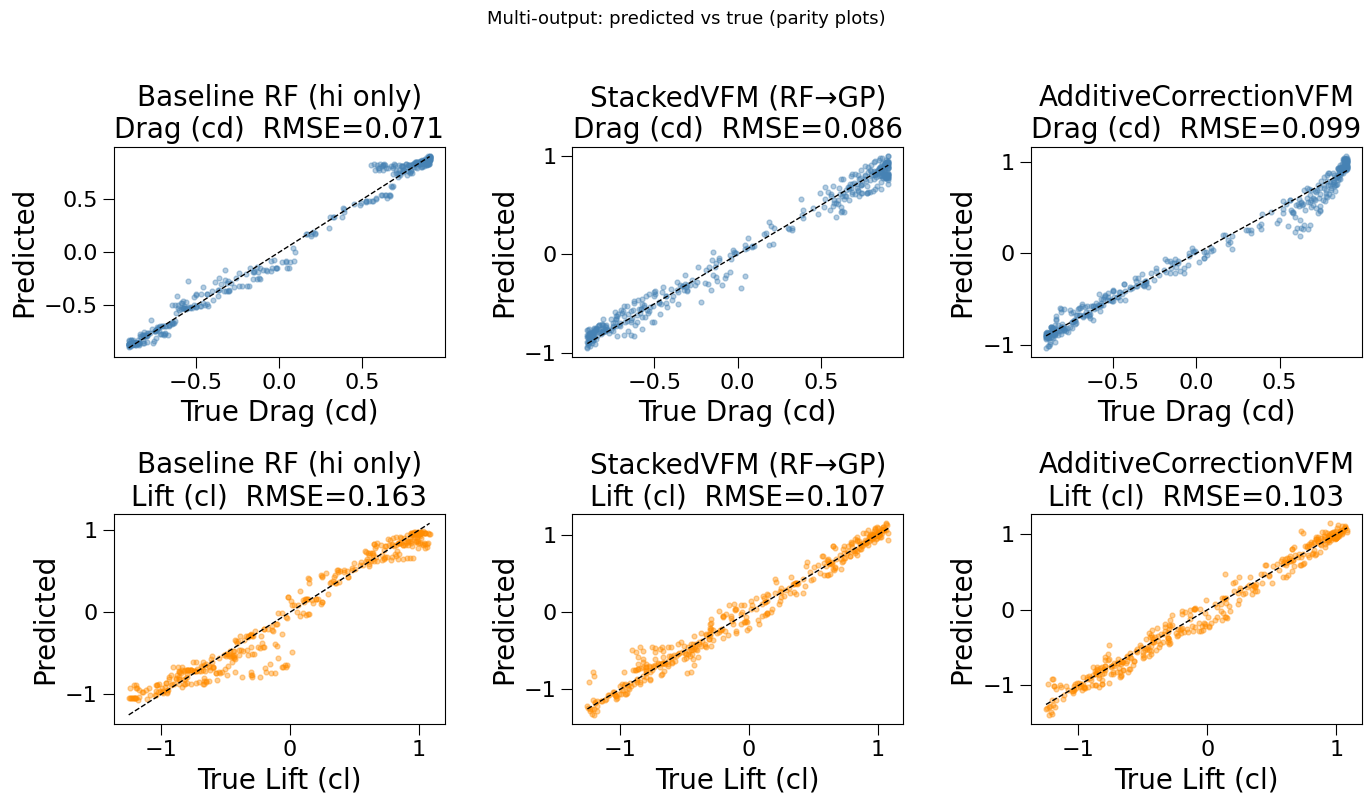

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

models = [
    ("Baseline RF (hi only)",         Y_base_mo),
    ("StackedVFM (RF→GP)",            Y_stacked_mo),
    ("AdditiveCorrectionVFM",         Y_add_mo),
]

for row, out_idx in enumerate([0, 1]):
    for col, (model_name, Y_pred) in enumerate(models):
        ax = axes[row, col]
        r = rmse(Y_test_mo, Y_pred)[out_idx]
        ax.scatter(Y_test_mo[:, out_idx], Y_pred[:, out_idx],
                   s=12, alpha=0.4, c='steelblue' if row == 0 else 'darkorange')
        lims = [Y_test_mo[:, out_idx].min(), Y_test_mo[:, out_idx].max()]
        ax.plot(lims, lims, 'k--', lw=1)
        ax.set_xlabel(f'True {output_names[out_idx]}')
        ax.set_ylabel(f'Predicted')
        ax.set_title(f'{model_name}\n{output_names[out_idx]}  RMSE={r:.3f}')

plt.suptitle('Multi-output: predicted vs true (parity plots)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
<a id='comparison'></a>
## 9. Model Comparison

Summary of all models evaluated in this tutorial on the 1D benchmark.

In [19]:
import pandas as pd

results_1d = [
    ("MultiFidelity (lo-level, RF)",        rmse(Y_test, Y_mfs_lo).item()),
    ("MultiFidelity (hi-level, RF)",        rmse(Y_test, Y_mfs_hi).item()),
    ("Baseline RF (hi only)",               rmse(Y_test, Y_baseline).item()),
    ("StackedVFM (RF/RF)",                  rmse(Y_test, Y_stacked).item()),
    ("StackedVFM (RF→GP)",                  rmse(Y_test, Y_rf_gp).item()),
    ("StackedVFM (RF→GP + std aug)",        rmse(Y_test, Y_std_pred).item()),
    ("StackedVFM 3-level (RF/GB/GP)",       rmse(Y_test, Y_3).item()),
    ("AdditiveCorrectionVFM (RF+GP)",       rmse(Y_test, Y_add).item()),
]

df = pd.DataFrame(results_1d, columns=["Model", "RMSE"])
df = df.sort_values("RMSE").reset_index(drop=True)
df["RMSE"] = df["RMSE"].round(4)
df

,Model,RMSE
0,"MultiFidelity (lo-level, RF)",0.2259
1,StackedVFM (RF/RF),0.3479
2,AdditiveCorrectionVFM (RF+GP),0.4841
3,"MultiFidelity (hi-level, RF)",0.6402
4,Baseline RF (hi only),0.6544
5,StackedVFM (RF→GP + std aug),1.1526
6,StackedVFM (RF→GP),1.2975
7,StackedVFM 3-level (RF/GB/GP),5.1448


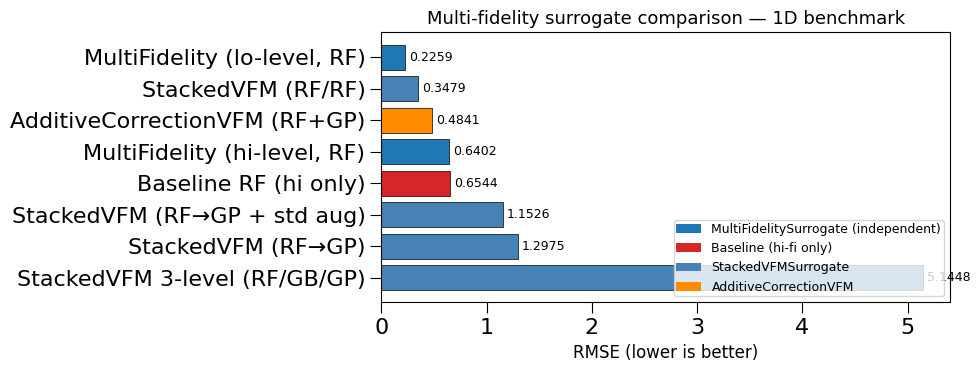

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ['tab:blue' if 'Multi' in m else
          'tab:red'  if 'Baseline' in m else
          'darkorange' if 'Additive' in m else
          'steelblue'
          for m in df["Model"]]

bars = ax.barh(df["Model"], df["RMSE"], color=colors, edgecolor='k', lw=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('RMSE (lower is better)', fontsize=12)
ax.set_title('Multi-fidelity surrogate comparison — 1D benchmark', fontsize=13)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue',   label='MultiFidelitySurrogate (independent)'),
    Patch(facecolor='tab:red',    label='Baseline (hi-fi only)'),
    Patch(facecolor='steelblue',  label='StackedVFMSurrogate'),
    Patch(facecolor='darkorange', label='AdditiveCorrectionVFM'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

---
<a id='guide'></a>
## 10. When to Use Which Class

| Situation | Recommended class |
|---|---|
| You want to query any level independently, with no cross-fidelity learning | `MultiFidelitySurrogate` |
| The fidelity gap is **nonlinear** or involves regional differences | `StackedVFMSurrogate` |
| You have **3 or more** fidelity levels | `StackedVFMSurrogate` |
| Different regions need different surrogate families | `StackedVFMSurrogate` with list `surrogate_cls` |
| The fidelity gap is approximately an **additive smooth shift** | `AdditiveCorrectionVFM` |
| You want a simple **diagnostic decomposition** `f_lo + δ` | `AdditiveCorrectionVFM` (use `predict_components`) |
| You need **calibrated prediction intervals** | Any class — call `wrap_conformal` + `conformal_predict` |
| High-fidelity data is very scarce (< 10 points) | `AdditiveCorrectionVFM` with GP correction or `StackedVFMSurrogate` with GP at hi level |
| Output space is multi-output | All three classes handle this natively |

### Parameter cheat-sheet

```python
# MultiFidelitySurrogate
MultiFidelitySurrogate(surrogate_cls=RandomForestSurrogate, fidelity_levels=["lo", "hi"])
model.fit({"lo": (X_lo, Y_lo), "hi": (X_hi, Y_hi)})
model.predict(X_test, level="hi")          # specify which level

# StackedVFMSurrogate
StackedVFMSurrogate(
    fidelity_levels=["lo", "med", "hi"],   # ordered lowest → highest
    surrogate_cls=[RF, GB, GP],            # one class or a list
    surrogate_params=[{}, {}, {"alpha": 1e-6}],
    augment_with_std=True,                 # pass predicted stds as features
)
model.fit({"lo": (X_lo, Y_lo), "med": (X_med, Y_med), "hi": (X_hi, Y_hi)})
model.predict(X_test)                      # defaults to highest level
model.predict(X_test, level="med")        # or specify intermediate level
model.predict(X_test, return_std=True)    # std from hi-level surrogate

# AdditiveCorrectionVFM
AdditiveCorrectionVFM(
    lo_surrogate_cls=RandomForestSurrogate,
    hi_surrogate_cls=GaussianProcessSurrogate,  # models the correction delta
)
model.fit({"lo": (X_lo, Y_lo), "hi": (X_hi, Y_hi)})
y_pred, y_std = model.predict(X_test, return_std=True)  # quadrature uncertainty
f_lo, delta   = model.predict_components(X_test)         # decomposed prediction

# Conformal intervals (any multi-fidelity class)
model.fit(data_train)
model.wrap_conformal(X_cal, y_cal)         # calibrate on held-out hi-fi points
y_lower, y_upper = model.conformal_predict(X_test, alpha=0.1)  # 90% coverage
```

In [21]:
# Quick sanity check: all key APIs work end-to-end
print("=== API smoke test ===")

# MultiFidelitySurrogate
m = MultiFidelitySurrogate(RandomForestSurrogate, ["lo", "hi"])
m.fit(data)
assert m.predict(X_test[:5], level="hi").shape == (5, 1)
print("MultiFidelitySurrogate          OK")

# StackedVFMSurrogate
s = StackedVFMSurrogate(fidelity_levels=["lo", "hi"])
s.fit(data)
y, std = s.predict(X_test[:5], return_std=True)
assert y.shape == (5, 1)
s.wrap_conformal(X_hi[:5], Y_hi[:5])
lo_cp, hi_cp = s.conformal_predict(X_test[:5], alpha=0.1)
assert (hi_cp >= lo_cp).all()
print("StackedVFMSurrogate             OK")

# AdditiveCorrectionVFM
a = AdditiveCorrectionVFM()
a.fit(data)
y_add, std_add = a.predict(X_test[:5], return_std=True)
f_lo, delta = a.predict_components(X_test[:5])
assert np.allclose(y_add, f_lo + delta)
a.wrap_conformal(X_hi[:5], Y_hi[:5])
lo_cp2, hi_cp2 = a.conformal_predict(X_test[:5], alpha=0.1)
assert (hi_cp2 >= lo_cp2).all()
print("AdditiveCorrectionVFM           OK")

print("\nAll assertions passed.")

=== API smoke test ===
MultiFidelitySurrogate          OK
StackedVFMSurrogate             OK
AdditiveCorrectionVFM           OK

All assertions passed.


---

## References

- Perdikaris, P., Raissi, M., Damianou, A., Lawrence, N. D., & Karniadakis, G. E. (2017). **Nonlinear information fusion algorithms for data-efficient multi-fidelity modelling.** *Proceedings of the Royal Society A*, 473(2198).

- Kennedy, M. C., & O'Hagan, A. (2000). **Predicting the output from a complex computer code when fast approximations are available.** *Biometrika*, 87(1), 1–13.

- Angelopoulos, A. N., & Bates, S. (2021). **A gentle introduction to conformal prediction and distribution-free uncertainty quantification.** arXiv:2107.07511.